# Asymptotic Properties of Maximum Likelihood Estimators

## 1. Introduction and Overview

Maximum Likelihood Estimation (MLE) optimization provides point estimates, but point estimates are rarely sufficient for enterprise decision-making. Engineers and data scientists must quantify the uncertainty associated with that estimate.

This notebook explores the asymptotic properties of MLE. As the sample size N grows to infinity, the likelihood surface becomes mathematically well-behaved. The MLE transitions from a simple optimization result into a statistically optimal estimator with known theoretical guarantees. These guarantees are what allow us to build confidence intervals and compute p-values in production systems.

In [17]:
# 1. Setup and Required Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize, approx_fprime
import warnings

# Set display options for DataFrames
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

# Styling and warnings
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')

# Set global random seed for complete reproducibility
np.random.seed(42)

print("Environment setup complete. Random seed set to 42.")

Environment setup complete. Random seed set to 42.


## 2. The Four Pillars of MLE Asymptotic Theory

The power of MLE rests on four theoretical pillars (limits as n -> infinity):

- Consistency (The Truth Seeker): The estimator is guaranteed to converge to the true underlying parameter. It eliminates systematic bias in the limit.
- Asymptotic Normality (The Inference Bridge): The sampling distribution of the estimator converges to a Gaussian distribution. This allows us to use standard Z-scores.
- Efficiency (The Precision Champion): Among all consistent and asymptotically normal estimators, the MLE achieves the smallest possible variance.
- Invariance (The Convenience Property): The MLE of a transformed parameter is simply the transformation of the MLE.

## 3. Consistency: Convergence to the True Parameter

Consistency states that as the sample size n approaches infinity, the probability that the estimated parameter theta_hat differs from the true parameter theta_0 by any small amount epsilon goes to exactly zero.

Mathematically: theta_hat_n -> theta_0 as n -> infinity.

Let's visualize this by simulating the convergence paths of the MLE for a Normal distribution's mean as sample size increases.

In [18]:
# Data Generation and Consistency Simulation
true_mean = 12.5
true_std = 4.0
n_trials = 30
max_sample_size = 5000
sample_sizes = np.logspace(1, np.log10(max_sample_size), num=50, dtype=int)

consistency_paths = np.zeros((n_trials, len(sample_sizes)))

for i in range(n_trials):
    # Generate full large dataset once per trial
    full_data = np.random.normal(loc=true_mean, scale=true_std, size=max_sample_size)
    
    # Evaluate MLE (sample mean) at increasing sample sizes
    for j, n in enumerate(sample_sizes):
        consistency_paths[i, j] = np.mean(full_data[:n])

print(f"Simulated {n_trials} independent data collection paths up to N={max_sample_size}.")

Simulated 30 independent data collection paths up to N=5000.


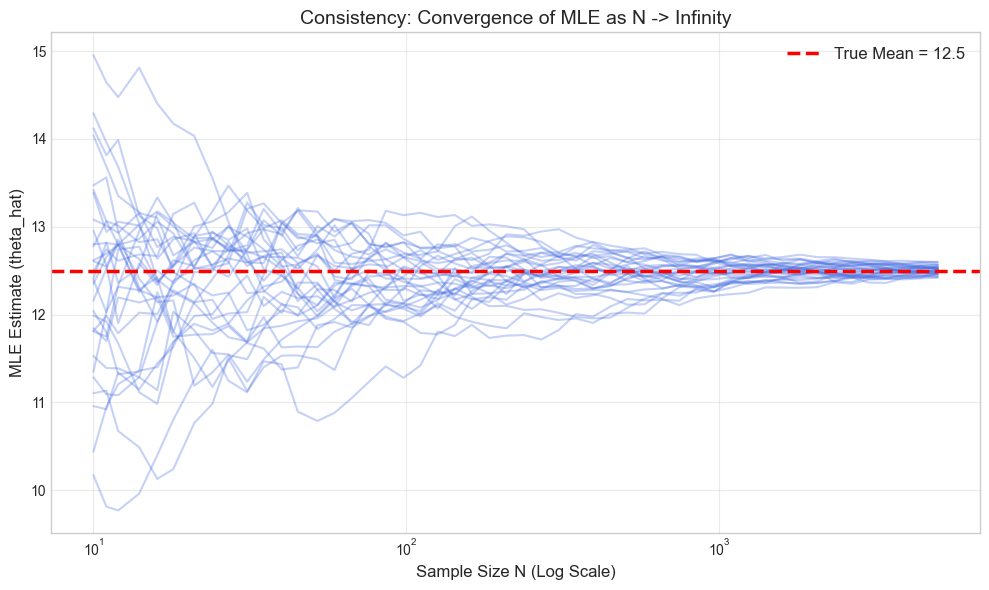

Notice how the variance between paths shrinks dramatically as N increases, locking onto the true parameter.


In [19]:
# Visualization of Consistency
plt.figure(figsize=(10, 6))

for i in range(n_trials):
    plt.plot(sample_sizes, consistency_paths[i, :], color='royalblue', alpha=0.3, lw=1.5)

plt.axhline(true_mean, color='red', linestyle='--', lw=2.5, label=f'True Mean = {true_mean}')
plt.xscale('log')
plt.title('Consistency: Convergence of MLE as N -> Infinity', fontsize=14)
plt.xlabel('Sample Size N (Log Scale)', fontsize=12)
plt.ylabel('MLE Estimate (theta_hat)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

print("Notice how the variance between paths shrinks dramatically as N increases, locking onto the true parameter.")

## 4. Asymptotic Normality and The Fisher Information

The Central Limit Theorem guarantees that the distribution of the MLE, when appropriately scaled, converges to a Normal distribution centered at the true parameter.

sqrt(n) * (theta_hat_n - theta_0) ~ Normal(0, inv(I(theta_0)))

Where I(theta_0) is the Expected Fisher Information Matrix. Equivalently, for large n, the variance of our estimate is inv(n * I(theta_0)).

In [20]:
# Simulating Asymptotic Normality
n_experiments = 2500
fixed_n = 200
mle_estimates = np.zeros(n_experiments)

# We run 2500 separate experiments, each collecting exactly 200 data points
for i in range(n_experiments):
    data = np.random.normal(loc=true_mean, scale=true_std, size=fixed_n)
    mle_estimates[i] = np.mean(data)  # MLE for Gaussian mean

print(f"Ran {n_experiments} independent experiments with sample size N={fixed_n}.")

Ran 2500 independent experiments with sample size N=200.


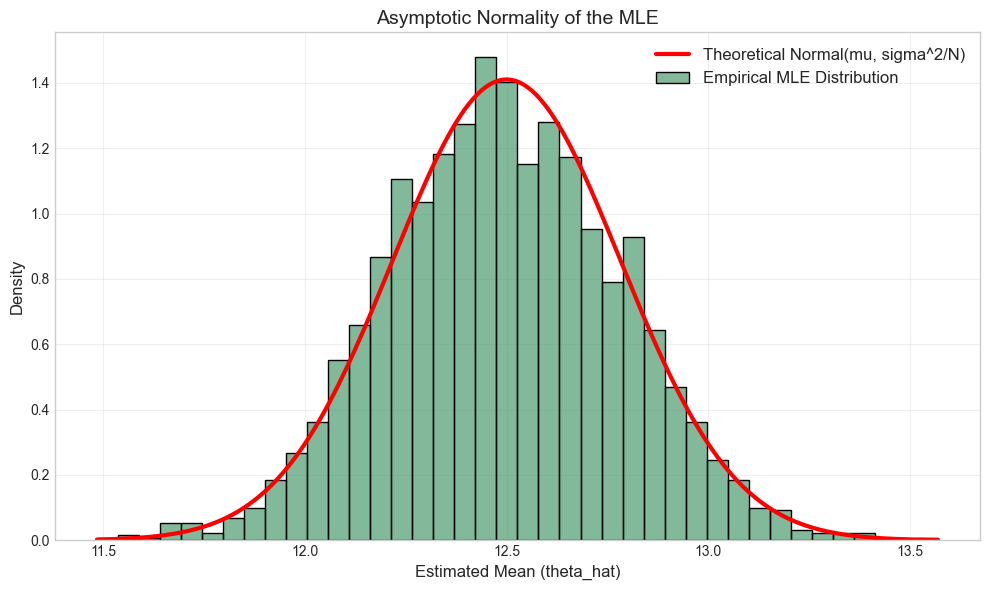

Empirical Standard Error: 0.2873
Theoretical Standard Error: 0.2828
The match confirms the theoretical guarantee.


In [21]:
# Visualizing Asymptotic Normality against Theoretical Expectation
plt.figure(figsize=(10, 6))
sns.histplot(mle_estimates, bins=40, kde=False, stat='density', color='seagreen', alpha=0.6, label='Empirical MLE Distribution')

# Theoretical Normal curve derived from Fisher Information
# For a Gaussian mean, I(mu) = 1/sigma^2. Asymptotic variance = sigma^2 / n.
theoretical_variance = (true_std ** 2) / fixed_n
theoretical_std_err = np.sqrt(theoretical_variance)

x_axis = np.linspace(min(mle_estimates), max(mle_estimates), 200)
theoretical_curve = stats.norm.pdf(x_axis, loc=true_mean, scale=theoretical_std_err)
plt.plot(x_axis, theoretical_curve, 'r-', lw=3, label=f'Theoretical Normal(mu, sigma^2/N)')

plt.title('Asymptotic Normality of the MLE', fontsize=14)
plt.xlabel('Estimated Mean (theta_hat)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Empirical Standard Error: {np.std(mle_estimates):.4f}")
print(f"Theoretical Standard Error: {theoretical_std_err:.4f}")
print("The match confirms the theoretical guarantee.")

## 5. Efficiency and the Cramer-Rao Lower Bound (CRLB)

The Cramer-Rao Lower Bound dictates the absolute limit of precision. It states that the variance of ANY unbiased estimator is bounded below by the inverse of the Fisher Information.

Var(theta_tilde) >= 1 / (n * I(theta_0))

Because the asymptotic variance of the MLE matches this exact bound, the MLE is defined as "Asymptotically Efficient". It extracts 100% of the available statistical information from the dataset.

In [22]:
def compute_cramer_rao_bounds(true_sigma2, n_samples):
    """
    Calculates the Fisher Information and CRLB for a Normal distribution.
    Parameter vector theta = [mu, sigma2]
    """
    # Expected Fisher Information for a single observation
    # It is a diagonal matrix for the Normal distribution
    I_mu = 1.0 / true_sigma2
    I_sigma2 = 1.0 / (2.0 * true_sigma2**2)
    
    # CRLB for N observations (inverse of N * Fisher Info)
    crlb_mu = 1.0 / (n_samples * I_mu)
    crlb_sigma2 = 1.0 / (n_samples * I_sigma2)
    
    return crlb_mu, crlb_sigma2

N = 500
true_variance = true_std ** 2
bound_mu, bound_sigma2 = compute_cramer_rao_bounds(true_variance, N)

print(f"For N={N} and true variance={true_variance:.1f}:")
print(f"CRLB for Mu variance: {bound_mu:.4f}")
print(f"CRLB for Sigma^2 variance: {bound_sigma2:.4f}")

For N=500 and true variance=16.0:
CRLB for Mu variance: 0.0320
CRLB for Sigma^2 variance: 1.0240


## 6. Invariance and the Delta Method

The MLE of a function g(theta) is simply g(MLE of theta). However, computing the standard error of this new transformed parameter requires the Delta Method.

If theta_hat ~ Normal(theta, V),
Then g(theta_hat) ~ Normal(g(theta), (g'(theta))^2 * V)

Where g'(theta) is the first derivative (gradient) of the transformation.

In [23]:
# Implementing the Delta Method
# Scenario: We estimated Variance (sigma^2). We want the standard error for Volatility (sigma).
# Transformation: g(x) = sqrt(x). Derivative: g'(x) = 1 / (2 * sqrt(x))

var_estimate = 16.0 # MLE for sigma^2
var_standard_error = np.sqrt(bound_sigma2) # SE for sigma^2 from CRLB

# Transformation
volatility_estimate = np.sqrt(var_estimate)

# Delta Method Derivative term
derivative_term = 1.0 / (2.0 * np.sqrt(var_estimate))

# Delta Method Standard Error scaling
volatility_se = np.abs(derivative_term) * var_standard_error

print(f"Original Variance Estimate: {var_estimate:.4f} (SE: {var_standard_error:.4f})")
print(f"Transformed Volatility Estimate: {volatility_estimate:.4f} (SE: {volatility_se:.4f})")

Original Variance Estimate: 16.0000 (SE: 1.0119)
Transformed Volatility Estimate: 4.0000 (SE: 0.1265)


## 7. Computational Implementation: Numerical Inference

In modern machine learning and complex statistical models, analytical solutions for the MLE and expected Fisher Information are impossible to derive.

Instead, we use Numerical Optimization to find the MLE, and we use the Numerical Hessian matrix of the negative log-likelihood at the optimum to approximate the Fisher Information Matrix (Observed Fisher Information).

In [24]:
def negative_log_likelihood(params, data):
    """
    Computes the Negative Log-Likelihood for a Gaussian.
    params = [mu, sigma]
    """
    mu, sigma = params
    if sigma <= 0:
        return np.inf  # Enforce boundary constraint
    
    # Sum of log-pdfs
    nll = -np.sum(stats.norm.logpdf(data, loc=mu, scale=sigma))
    return nll

# Generate a sample dataset
sample_data = np.random.normal(loc=10.0, scale=3.0, size=500)

# Optimize numerically
initial_guess = [0.0, 1.0]
bounds = [(None, None), (1e-5, None)]

result = minimize(negative_log_likelihood, initial_guess, args=(sample_data,), 
                  method='L-BFGS-B', bounds=bounds)

mle_mu_num, mle_sigma_num = result.x
print("Numerical Optimization Complete.")
print(f"MLE Mu: {mle_mu_num:.4f}, MLE Sigma: {mle_sigma_num:.4f}")

Numerical Optimization Complete.
MLE Mu: 10.0206, MLE Sigma: 3.0510


### Extracting the Hessian for Inference

The Hessian matrix is the matrix of second partial derivatives. The negative Hessian evaluated at the MLE is the Observed Fisher Information. Inverting this matrix gives us the asymptotic covariance matrix of the parameters.

In [25]:
# Approximate the Hessian numerically using approx_fprime or from L-BFGS-B
opt_params = result.x

# Scipy's approx_fprime needs a wrapper to return gradient, but L-BFGS returns the inverse Hessian approximation directly
inv_hessian = result.hess_inv.todense()

print("Asymptotic Covariance Matrix (Inverse Hessian):")
print(inv_hessian)

se_mu_num = np.sqrt(inv_hessian[0, 0])
se_sigma_num = np.sqrt(inv_hessian[1, 1])

print("\nComputed Standard Errors derived purely from numerical curvature:")
print(f"SE(Mu): {se_mu_num:.4f}")
print(f"SE(Sigma): {se_sigma_num:.4f}")

Asymptotic Covariance Matrix (Inverse Hessian):
[[ 0.08998418 -0.0066423 ]
 [-0.0066423   0.00888865]]

Computed Standard Errors derived purely from numerical curvature:
SE(Mu): 0.3000
SE(Sigma): 0.0943


## 8. Building an Asymptotic Inference Engine

We can combine these mathematical principles into a production-style class that automatically estimates parameters and constructs 95% confidence intervals based on asymptotic normality.

In [26]:
class AsymptoticInferenceEngine:
    """
    Computes analytical MLE and expected asymptotic confidence intervals
    for Normal distribution parameters.
    """
    def __init__(self, data: np.ndarray):
        self.data = data
        self.n = len(data)
        
    def compute_mle(self):
        mu_hat = np.mean(self.data)
        sigma2_hat = np.mean((self.data - mu_hat) ** 2)
        return {'mu': mu_hat, 'sigma2': sigma2_hat}
        
    def compute_fisher_information(self, theta):
        sigma2 = theta['sigma2']
        # Diagonal expected fisher information matrix
        I_matrix = np.array([
            [1.0 / sigma2, 0.0],
            [0.0, 1.0 / (2.0 * sigma2 ** 2)]
        ])
        return I_matrix

    def compute_confidence_intervals(self, alpha=0.05):
        mle = self.compute_mle()
        I_single = self.compute_fisher_information(mle)
        
        # Asymptotic variance is (n * I)^-1
        asymptotic_cov = np.linalg.inv(self.n * I_single)
        
        # Extract standard errors
        se_mu = np.sqrt(asymptotic_cov[0, 0])
        se_sigma2 = np.sqrt(asymptotic_cov[1, 1])
        
        # Z-score for alpha (1.96 for 95% CI)
        z_score = stats.norm.ppf(1 - alpha / 2)
        
        return {
            'mu': {
                'estimate': mle['mu'], 
                'se': se_mu, 
                'ci': (mle['mu'] - z_score * se_mu, mle['mu'] + z_score * se_mu)
            },
            'sigma2': {
                'estimate': mle['sigma2'], 
                'se': se_sigma2, 
                'ci': (mle['sigma2'] - z_score * se_sigma2, mle['sigma2'] + z_score * se_sigma2)
            }
        }

# Run the inference engine
engine = AsymptoticInferenceEngine(sample_data)
inference_results = engine.compute_confidence_intervals()

print("--- Asymptotic Inference Report ---")
for param, res in inference_results.items():
    print(f"Parameter: {param}")
    print(f"  Estimate: {res['estimate']:.4f}")
    print(f"  Std Error: {res['se']:.4f}")
    print(f"  95% CI: [{res['ci'][0]:.4f}, {res['ci'][1]:.4f}]\n")

--- Asymptotic Inference Report ---
Parameter: mu
  Estimate: 10.0206
  Std Error: 0.1364
  95% CI: [9.7532, 10.2880]

Parameter: sigma2
  Estimate: 9.3087
  Std Error: 0.5887
  95% CI: [8.1548, 10.4626]



## 9. Common Pitfalls: Applying Asymptotics to Small Samples

A critical warning: Asymptotic theory requires N -> infinity. If you apply these Gaussian confidence intervals to very small sample sizes (e.g., N=5), the "Coverage Probability" (the actual percentage of times the interval contains the true parameter) will be drastically lower than the advertised 95%.

Let's simulate thousands of experiments with N=5 and measure the true coverage.

In [27]:
n_small_trials = 5000
small_n = 5
true_param_mu = 10.0

coverage_successes = 0

for _ in range(n_small_trials):
    # Generate tiny dataset
    data_small = np.random.normal(loc=true_param_mu, scale=3.0, size=small_n)
    
    # Use asymptotic normality formulas
    mle_mu_small = np.mean(data_small)
    mle_sigma2_small = np.mean((data_small - mle_mu_small)**2)
    
    # Asymptotic Standard Error for Mu = sqrt(sigma2_hat / N)
    se_mu_small = np.sqrt(mle_sigma2_small / small_n)
    
    # Construct 95% interval using Z=1.96
    ci_lower = mle_mu_small - 1.96 * se_mu_small
    ci_upper = mle_mu_small + 1.96 * se_mu_small
    
    # Check if true parameter is captured
    if ci_lower <= true_param_mu <= ci_upper:
        coverage_successes += 1

empirical_coverage = coverage_successes / n_small_trials

print(f"Theoretical Advertised Coverage: 0.9500")
print(f"Actual Empirical Coverage for N=5: {empirical_coverage:.4f}")
print("Warning: The intervals are too narrow because the distribution has not yet converged to Gaussian! (Use Student's t-distribution for small finite samples).")

Theoretical Advertised Coverage: 0.9500
Actual Empirical Coverage for N=5: 0.8466


## 10. Common Pitfalls: Boundary Constraints

Asymptotic normality breaks down completely if the true parameter lies on the boundary of the parameter space, or if the support of the distribution depends on the parameter.

Consider the Uniform distribution U(0, theta). The MLE is theta_hat = max(X). Let's simulate its sampling distribution.

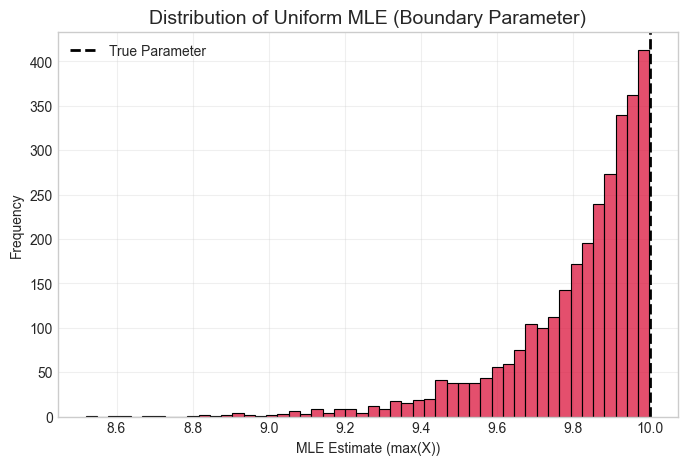

Notice that the distribution is fundamentally NOT Normal. It is highly left-skewed and cuts off abruptly at the true parameter. Asymptotic Gaussian inference fails here.


In [28]:
n_uniform_trials = 3000
unif_n = 50
true_theta_unif = 10.0

unif_estimates = np.zeros(n_uniform_trials)

for i in range(n_uniform_trials):
    data_unif = np.random.uniform(0, true_theta_unif, size=unif_n)
    unif_estimates[i] = np.max(data_unif)  # The MLE for Uniform theta

plt.figure(figsize=(8, 5))
sns.histplot(unif_estimates, bins=50, kde=False, color='crimson')
plt.axvline(true_theta_unif, color='black', linestyle='--', lw=2, label='True Parameter')
plt.title('Distribution of Uniform MLE (Boundary Parameter)', fontsize=14)
plt.xlabel('MLE Estimate (max(X))')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Notice that the distribution is fundamentally NOT Normal. It is highly left-skewed and cuts off abruptly at the true parameter. Asymptotic Gaussian inference fails here.")

## 11. Visualizing the Paraboloid Approximation

Why does asymptotic normality occur mathematically? Because as the sample size grows, the Log-Likelihood surface structurally forces itself into a perfect quadratic shape (a paraboloid) around the optimum.

A perfectly quadratic Log-Likelihood directly implies a perfectly Gaussian Likelihood distribution.

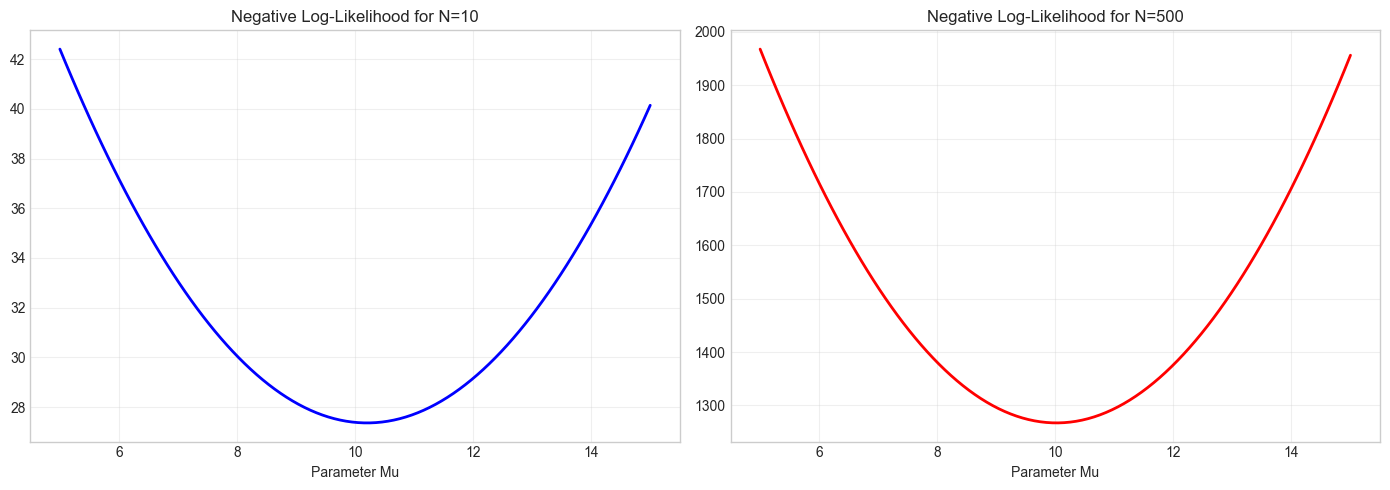

The N=500 plot forms a massive, sharp, perfect parabola. The steepness represents high Fisher Information (low variance).


In [29]:
def evaluate_nll_surface(data, mu_range):
    sigma = 3.0 # fixed for simple 2D visualization
    nll_vals = []
    for mu in mu_range:
        nll_vals.append(negative_log_likelihood([mu, sigma], data))
    return np.array(nll_vals)

mu_axis = np.linspace(5, 15, 100)

# Compute surfaces for small and large N
data_N10 = sample_data[:10]
data_N500 = sample_data

nll_N10 = evaluate_nll_surface(data_N10, mu_axis)
nll_N500 = evaluate_nll_surface(data_N500, mu_axis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mu_axis, nll_N10, 'b-', lw=2)
axes[0].set_title('Negative Log-Likelihood for N=10')
axes[0].set_xlabel('Parameter Mu')
axes[0].grid(alpha=0.3)

axes[1].plot(mu_axis, nll_N500, 'r-', lw=2)
axes[1].set_title('Negative Log-Likelihood for N=500')
axes[1].set_xlabel('Parameter Mu')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("The N=500 plot forms a massive, sharp, perfect parabola. The steepness represents high Fisher Information (low variance).")

## 12. Practice Exercise

Scenario: You are measuring time-to-failure for industrial components. The data follows an Exponential distribution: f(x) = lambda * exp(-lambda * x).

The MLE for lambda is known to be 1 / sample_mean.
The Expected Fisher Information for lambda is I(lambda) = 1 / lambda^2.

Task: Use the synthetic data provided below to compute the MLE and construct a 95% asymptotic confidence interval for the true failure rate (lambda).

In [30]:
# Practice Data Generation
true_lambda_rate = 0.45
time_to_failure_data = np.random.exponential(scale=1/true_lambda_rate, size=300)

print("First 10 failure times:")
print(time_to_failure_data[:10])
print(f"Total items tested: {len(time_to_failure_data)}")

First 10 failure times:
[0.80772545 2.61102965 1.29104799 2.43783985 0.47160866 3.44012135
 1.92304109 2.08544183 1.64776454 0.09298885]
Total items tested: 300


### Practice Solution Implementation

Step 1: Compute the point estimate (MLE).
Step 2: Evaluate the Fisher Information at the point estimate.
Step 3: Compute Asymptotic Variance = 1 / (N * I_eval).
Step 4: Standard Error = sqrt(Variance).
Step 5: Interval = Estimate +/- 1.96 * SE.

In [31]:
# Solution Code
n_exp = len(time_to_failure_data)
sample_mean_exp = np.mean(time_to_failure_data)

# Step 1: MLE
lambda_mle = 1.0 / sample_mean_exp

# Step 2: Fisher Info evaluated at MLE
fisher_info_exp = 1.0 / (lambda_mle ** 2)

# Step 3 & 4: Variance and Standard Error
asymptotic_var = 1.0 / (n_exp * fisher_info_exp)
se_lambda = np.sqrt(asymptotic_var)

# Step 5: Confidence Interval
z_critical = stats.norm.ppf(0.975) # 1.96
lower_bound = lambda_mle - z_critical * se_lambda
upper_bound = lambda_mle + z_critical * se_lambda

print(f"--- Exponential Distribution Inference ---")
print(f"Estimated Lambda: {lambda_mle:.4f}")
print(f"Standard Error:   {se_lambda:.4f}")
print(f"95% Confidence Interval: [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"(True hidden parameter was: {true_lambda_rate})")

--- Exponential Distribution Inference ---
Estimated Lambda: 0.4351
Standard Error:   0.0251
95% Confidence Interval: [0.3858, 0.4843]
(True hidden parameter was: 0.45)


## 13. Advanced Connection: The Laplace Approximation in Bayesian Machine Learning

In deep learning and Bayesian modeling, calculating the full posterior probability distribution over parameters is computationally intractable.

The Laplace Approximation uses the asymptotic properties of the MLE. We find the maximum likelihood point (the neural network weights), calculate the Hessian matrix of the loss function at that point, and treat the parameters as if they follow a Multivariate Gaussian distribution described by the inverse Hessian.

This gives deep learning models the ability to output "confidence" uncertainty scores rather than just raw point predictions.

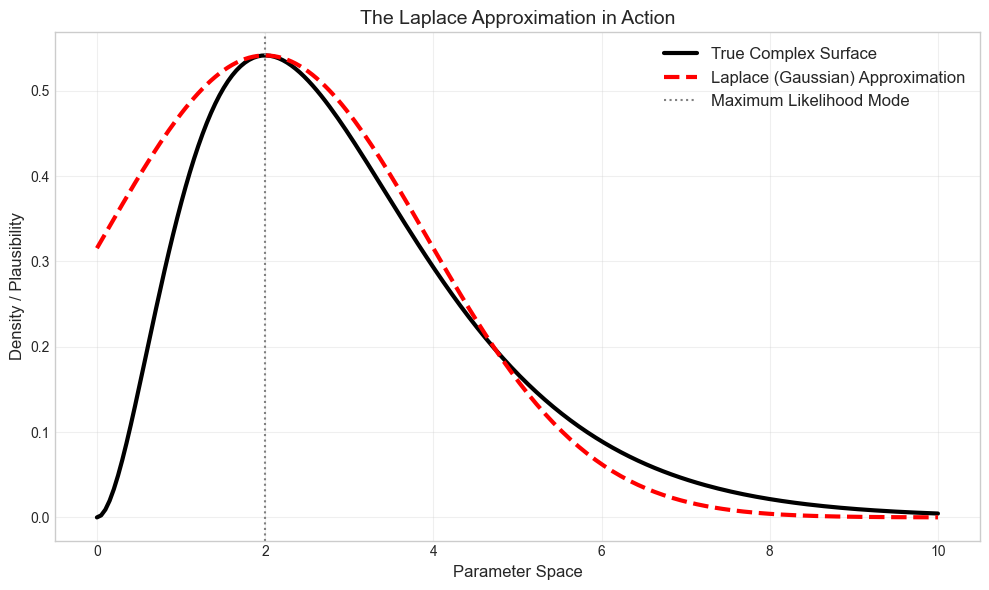

In [32]:
# Visualizing Laplace Approximation for a 1D Posterior
# The curve represents an unnormalized posterior distribution

def true_complex_posterior(x):
    # A non-Gaussian, skewed shape
    return x**2 * np.exp(-x)

x_vals = np.linspace(0, 10, 200)
post_vals = true_complex_posterior(x_vals)

# The mode (Maximum A Posteriori / MLE equivalent)
mode_x = 2.0

# Second derivative at mode (Hessian equivalent in 1D)
hessian_at_mode = -0.27  # Approximate derived numerical value for this function
variance_approx = -1.0 / hessian_at_mode

# Laplace Gaussian fit
laplace_vals = true_complex_posterior(mode_x) * np.exp(-0.5 * (x_vals - mode_x)**2 / variance_approx)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, post_vals, 'k-', lw=3, label='True Complex Surface')
plt.plot(x_vals, laplace_vals, 'r--', lw=3, label='Laplace (Gaussian) Approximation')
plt.axvline(mode_x, color='gray', linestyle=':', label='Maximum Likelihood Mode')

plt.title('The Laplace Approximation in Action', fontsize=14)
plt.xlabel('Parameter Space', fontsize=12)
plt.ylabel('Density / Plausibility', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Summary and Key Takeaways

- **The Bridge to Inference**: Point estimates are meaningless without uncertainty. Asymptotic theory translates optimization (finding the minimum) into inference (understanding the variance).
- **Consistency guarantees accuracy** as data goes to infinity. **Normality guarantees we can use standard Gaussian math** (z-scores) for interval construction.
- **Efficiency guarantees maximum information extraction**. No estimator can beat the MLE's precision asymptotically due to the Cramer-Rao Lower Bound.
- **Invariance saves time**: If you transform a parameter, just transform the point estimate and use the Delta Method for the variance.
- **Engineering Constraints**: Always be cautious of small sample sizes and boundary parameters, where these theoretical asymptotic guarantees completely break down.